## Attention Weight Patching Experiment
This experiment replaces attention head weights from one sample to another to explore whether this pushes representations off manifold. This experiment was inspired by a [tweet](https://x.com/piotrm1/status/1997050439788060982). Thanks Piotr.

What we do is use the attention weights from alternative countries and capitals instead of the attention weights for some target countries and capitals. We can compare the representations to both the source and the target representations to determine the degree of divergence. 

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import torch
import random
import gc
import dataclasses
from tqdm import tqdm
import os

import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForCausalLM

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3,4,5,6,7"
handles = None

def load_model_and_tokenizer(gpu_num, model_name="meta-llama/Meta-Llama-3-8B-Instruct"):
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16,
        device_map="auto",
    )
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
    )
    tokenizer.pad_token_id = tokenizer.eos_token_id
    model.eval()
    return model, tokenizer


def clear_hooks(input_hooks):
    for hook in input_hooks:
        hook.remove()
    input_hooks = []
    gc.collect()

In [3]:
try:
    from huggingface_hub import login
except:
    !pip install huggingface_hub
    from huggingface_hub import login
# either argue your huggingface token, or put it in a file
# named "your_token.txt" in the working directory
with open("your_token.txt", "r") as f:
    your_token = f.read().strip()
login(token=your_token)

In [4]:
# Choose model here
# Options are keys of model_names dict below
model_alias = "llama-3-instruct"

In [5]:
model_names = {
    "pythia-7b": "EleutherAI/pythia-6.9b",
    "llama-3-1": "meta-llama/Llama-3.1-8B",
    "llama-3-instruct":"meta-llama/Meta-Llama-3-8B-Instruct",
    "llama-2-7b-chat": "meta-llama/Llama-2-7b-chat-hf",
}
space_token = {
    "pythia-7b": "Ġ",
    "llama-3-1": "Ġ",
    "llama-2-7b-chat": "▁",
    "llama-3-instruct":" ",
}[model_alias]
model_name = model_names[model_alias]
model, tokenizer = load_model_and_tokenizer(0, model_name=model_name)
device = model.device

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [6]:
countries_df = pd.read_csv("data/countries.csv")
names_df = pd.read_csv("data/names.csv", index_col=0)

countries_to_capitals = countries_df.set_index("country")["capital"].to_dict()
names = names_df["name"].tolist()

# Keep only single token countries and names
countries_to_capitals = {k: v for k, v in countries_to_capitals.items() if len(tokenizer.encode(f" {k}", add_special_tokens=False)) == 1}
names = [n for n in names if len(tokenizer.encode(n, add_special_tokens=False)) == 1]

print(f"Number of countries: {len(countries_to_capitals)}, Sample: {list(countries_to_capitals.items())[:5]}")
print(f"Number of names: {len(names)}, Sample: {names[:5]}")

Number of countries: 125, Sample: [('Afghanistan', 'Kabul'), ('Albania', 'Tirana'), ('Algeria', 'Algiers'), ('Angola', 'Luanda'), ('Argentina', 'Buenos Aires')]
Number of names: 59, Sample: ['Michael', 'James', 'John', 'Robert', 'David']


In [7]:
@dataclasses.dataclass(frozen=True)
class Prompt:
    context: str
    questions: list[str]
    answers: list[str]
    names: list[str]
    countries: list[str]


def generate_prompt_pair(
    num_entities,
    all_names=names,
    all_countries=list(countries_to_capitals.keys()),
    parot=False,
):
    """
    Args:
        parot: bool
            if true, will simplify the problem such that the answer
            merely requires regurgitating the already specified city.
            Otherwise, model needs to associate the countries with
            their capitals.
    """
    cs = random.sample(all_countries, num_entities*2)
    ns = random.sample(all_names, num_entities*2)

    cs_1 = cs[:num_entities]
    ns_1 = ns[:num_entities]
    cs_2 = cs[num_entities:]
    ns_2 = ns[num_entities:]

    if parot:
        target_answers = [c for c in cs_1]
        source_answers = [c for c in cs_2]
        es_1 = [f"{n} lives in {c}." for c, n in zip(target_answers, ns_1)]
        es_2 = [f"{n} lives in {c}." for c, n in zip(source_answers, ns_2)]
        target_questions = [f"Question: What country does {n} live in?" for n in ns_1]
        source_questions = [f"Question: What country does {n} live in?" for n in ns_2]
    else:
        es_1 = [f"{n} lives in the capital city of {c}." for c, n in zip(cs_1, ns_1)]
        es_2 = [f"{n} lives in the capital city of {c}." for c, n in zip(cs_2, ns_2)]
        target_answers = [countries_to_capitals[c] for c in cs_1]
        source_answers = [countries_to_capitals[c] for c in cs_2]
        target_questions = [f"Question: Which city does {n} live in?" for n in ns_1]
        source_questions = [f"Question: Which city does {n} live in?" for n in ns_2]
    target_context =  f"Answer the question based on the context below. Keep the answer short.\n\nContext: {' '.join(es_1)}"
    source_context =  f"Answer the question based on the context below. Keep the answer short.\n\nContext: {' '.join(es_2)}"
    return (Prompt(
        context=target_context,
        questions=target_questions,
        answers=target_answers,
        names=ns_1,
        countries=cs_1,
    ), Prompt(
        context=source_context,
        questions=source_questions,
        answers=source_answers,
        names=ns_2,
        countries=cs_2,
    ))


In [8]:
parot = False # if true, task will be to predicted the provided attributes. if false, predict cities from attributes
target_prompt, source_prompt = generate_prompt_pair(2, parot=parot)
print("Target:", target_prompt.context)
print("Questions:", target_prompt.questions)
print("Answers:", target_prompt.answers)
print()
print("Source:", source_prompt.context)
print("Questions:", source_prompt.questions)
print("Answers", source_prompt.answers)

Target: Answer the question based on the context below. Keep the answer short.

Context: Amy lives in the capital city of Albania. Brian lives in the capital city of Tanzania.
Questions: ['Question: Which city does Amy live in?', 'Question: Which city does Brian live in?']
Answers: ['Tirana', 'Dodoma']

Source: Answer the question based on the context below. Keep the answer short.

Context: George lives in the capital city of Ecuador. Anthony lives in the capital city of Bolivia.
Questions: ['Question: Which city does George live in?', 'Question: Which city does Anthony live in?']
Answers ['Quito', 'La Paz']


In [9]:
def manual_decode(token_ids, tokenizer):
    decoded = []
    for tok in token_ids:
        decoded.append(tokenizer.decode(tok))
    return decoded
        
def batch_manual_decode(token_ids, tokenizer):
    all_decoded = []
    for samp in range(len(token_ids)):
        decoded = manual_decode(token_ids[samp], tokenizer)
        all_decoded.append(decoded)
    return all_decoded

In [10]:
def repeat_kv(hidden_states: torch.Tensor, n_rep: int) -> torch.Tensor:
    """
    This is the equivalent of torch.repeat_interleave(x, dim=1, repeats=n_rep). The hidden states go from (batch,
    num_key_value_heads, seqlen, head_dim) to (batch, num_attention_heads, seqlen, head_dim)
    """
    batch, num_key_value_heads, slen, head_dim = hidden_states.shape
    if n_rep == 1:
        return hidden_states
    hidden_states = hidden_states[:, :, None, :, :].expand(batch, num_key_value_heads, n_rep, slen, head_dim)
    return hidden_states.reshape(batch, num_key_value_heads * n_rep, slen, head_dim)

In [ ]:
def make_attn_hook(layer_idx, comms_dict):
    """
    Returns a hook that collects the attention weights for a given layer.
    """
    def hook(module, input, output):
        # For LLaMA impls, output may be (attn_output, attn_weights, ...)
        attn_output, attn_weights, *rest = output
        # Store the attention weights on CPU so we can reuse / modify them later
        comms_dict[layer_idx] = attn_weights.detach().cpu()
        return output

    return hook


def make_patch_hook(layer_idx, comms_dict):
    """
    Hook that *actually uses* patched attention weights.

    We recompute the attention output using the patched attention
    probabilities and the current value states, then return this
    modified output so it flows through the rest of the model.
    This assumes LLaMA-style attention with no KV cache (as used here).
    """

    def hook(module, input, output):
        # Unpack original outputs
        attn_output, attn_weights, *rest = output

        # If we don't have saved weights for this layer, do nothing
        if layer_idx not in comms_dict or attn_weights is None:
            return output

        # Saved (possibly patched) attention weights for this layer
        patch_weights = comms_dict[layer_idx].clone().to(attn_weights.device, dtype=attn_weights.dtype)

        # Align sequence dimensions (batch, heads, q_len, k_len)
        q_len, k_len = attn_weights.shape[-2], attn_weights.shape[-1]
        patch_weights = patch_weights[..., :q_len, :k_len]

        # ------------------------------------------------------------------
        # Recompute attn_output using patch_weights and current value states
        # ------------------------------------------------------------------
        hidden_states = comms_dict["hidden_states"][layer_idx][None].clone()  # [batch, q_len, hidden_size]
        bsz, q_len_actual, _ = hidden_states.size()

        # Project to value states
        n_heads = patch_weights.shape[1]
        input_shape = hidden_states.shape[:-1]
        hidden_shape = (*input_shape, -1, module.head_dim)
        value_states = module.v_proj(hidden_states).view(hidden_shape).transpose(1, 2)
        value_states = repeat_kv(value_states, module.num_key_value_groups)

        patched_attn_output = torch.matmul(patch_weights, value_states)
        patched_attn_output = patched_attn_output.transpose(1, 2).contiguous()
        patched_attn_output = patched_attn_output.reshape(*input_shape, -1).contiguous()
        patched_attn_output = module.o_proj(patched_attn_output)

        # Return modified attention output and patched weights so the
        # rest of the model uses the new attention computation
        return (patched_attn_output, patch_weights, *rest)

    return hook

In [12]:
def set_modified_attn_weights(main_attns, alt_attns, modify_index, comms_dict):
    for layer_idx, attn_weights in main_attns.items():
        comms_dict[layer_idx] = attn_weights.clone()
        comms_dict[layer_idx][..., modify_index, :] = alt_attns[layer_idx][..., modify_index, :]


In [ ]:
n_samples = 128
intervention_layers = None

model.set_attn_implementation('eager')
try:
    if handles:
        for h in handles:
            h.remove()
    patch_handles = None
except:
    pass

rows = []
main_hidden_states_list = []
alt_hidden_states_list = []
mod_hidden_states_list = []
for sample in tqdm(range(n_samples)):
    mp, ap = generate_prompt_pair(2)
    for query_entity_idx in range(4):
        comms_dict = {}
        
        query_entities = mp.names + ap.names
        questions = mp.questions + ap.questions
        if parot:
            main_prompt = mp.context + "\n" + questions[query_entity_idx] + f"\nAnswer: {query_entities[query_entity_idx]} lives in"
            alt_prompt = ap.context + "\n" + questions[query_entity_idx] + f"\nAnswer: {query_entities[query_entity_idx]} lives in"
        else:
            main_prompt = mp.context + "\n" + questions[query_entity_idx] + f"\nAnswer: {query_entities[query_entity_idx]} lives in the city of"
            alt_prompt = ap.context + "\n" + questions[query_entity_idx] + f"\nAnswer: {query_entities[query_entity_idx]} lives in the city of"

        main_prompt_tokens = tokenizer(main_prompt, return_tensors="pt").to(device)
        alt_prompt_tokens = tokenizer(alt_prompt, return_tensors="pt").to(device)
        main_ids = main_prompt_tokens["input_ids"]
        alt_ids = alt_prompt_tokens["input_ids"]

        main_decoded_tokens = manual_decode(main_prompt_tokens["input_ids"][0], tokenizer)
        main_n1_index = main_decoded_tokens.index(f"{space_token}{mp.names[0]}")
        main_n2_index = main_decoded_tokens.index(f"{space_token}{mp.names[1]}")
        main_c1_index = main_decoded_tokens.index(f"{space_token}{mp.countries[0]}")
        main_c2_index = main_decoded_tokens.index(f"{space_token}{mp.countries[1]}")

        alt_decoded_tokens = manual_decode(alt_prompt_tokens["input_ids"][0], tokenizer)
        alt_n1_index = alt_decoded_tokens.index(f"{space_token}{ap.names[0]}")
        alt_n2_index = alt_decoded_tokens.index(f"{space_token}{ap.names[1]}")
        alt_c1_index = alt_decoded_tokens.index(f"{space_token}{ap.countries[0]}")
        alt_c2_index = alt_decoded_tokens.index(f"{space_token}{ap.countries[1]}")
        if not (main_n1_index == alt_n1_index and main_n2_index == alt_n2_index and main_c1_index == alt_c1_index and main_c2_index == alt_c2_index):
            print("Mismatch in indices")
            continue

        main_a1_id = tokenizer(" " + mp.answers[0], add_special_tokens=False)["input_ids"][0]
        main_a2_id = tokenizer(" " + mp.answers[1], add_special_tokens=False)["input_ids"][0]
        alt_a1_id = tokenizer(" " + ap.answers[0], add_special_tokens=False)["input_ids"][0]
        alt_a2_id = tokenizer(" " + ap.answers[1], add_special_tokens=False)["input_ids"][0]

        # Attach hooks to get attention weights
        handles = []
        for i, block in enumerate(model.model.layers):
            handles.append(block.self_attn.register_forward_hook(make_attn_hook(i, comms_dict=comms_dict)))

        # Get hidden states
        with torch.no_grad():
            main_out = model(main_ids, output_hidden_states=True, output_attentions=True)
            main_hidden_states = torch.vstack(main_out.hidden_states)
            midxs = [main_n1_index, main_n2_index, main_c1_index, main_c2_index]
            main_hidden_states_list.append(
                main_hidden_states[:,midxs]
            )
            main_attns = {**comms_dict}
            alt_out = model(alt_ids, output_hidden_states=True, output_attentions=True)
            alt_hidden_states = torch.vstack(alt_out.hidden_states)
            aidxs = [alt_n1_index, alt_n2_index, alt_c1_index, alt_c2_index]
            alt_hidden_states_list.append(alt_hidden_states[:,aidxs])
            alt_attns = {**comms_dict}

        # Remove hooks
        for h in handles:
            h.remove()

        # #####################################################################
        # # Sanity Check That Patched Attention Hook Can Reproduce Main Result
        # handles = []
        # for i, block in enumerate(model.model.layers):
        #     handles.append(block.self_attn.register_forward_hook(make_patch_hook(i, comms_dict=comms_dict)))

        # with torch.no_grad():
        #     for k,v in main_attns.items():
        #         comms_dict[k] = v
        #     mod_hidden_states = [model.model.layers[i].input_layernorm(h) for i, h in enumerate(main_hidden_states[:-1])]
        #     comms_dict["hidden_states"] = mod_hidden_states
        #     mod_out = model(main_ids, output_hidden_states=True, output_attentions=True)
        #     modified_hidden_states = torch.vstack(mod_out.hidden_states)

        # for h in handles:
        #     h.remove()
        # handles = None
        # assert torch.allclose(modified_hidden_states, main_hidden_states)
        # # Sanity Check
        # #####################################################################

        hlist = []
        for modify_index in [main_n1_index, main_n2_index, main_c1_index, main_c2_index]:
            handles = []
            for i, block in enumerate(model.model.layers):
                if intervention_layers is None or i in intervention_layers:
                    handles.append(block.self_attn.register_forward_hook(make_patch_hook(i, comms_dict=comms_dict)))

            set_modified_attn_weights( main_attns, alt_attns, modify_index, comms_dict,)
            with torch.no_grad():
                comms_dict["hidden_states"] = [model.model.layers[i].input_layernorm(h) for i, h in enumerate(main_hidden_states[:-1])]
                mod_out = model(main_ids, output_hidden_states=True, output_attentions=True)
                modified_hidden_states = torch.vstack(mod_out.hidden_states)
                hlist.append(modified_hidden_states[:,[modify_index]])

            for h in handles:
                h.remove()
            handles = None

            modified_log_probs = F.log_softmax(mod_out.logits[0,-1,:], dim=-1)
            rows += [
                {
                    "run": 0,
                    "query_name": ["e0", "e1", "e0'", "e1'"][query_entity_idx],
                    "attribute": ["a0", "a1", "a0'", "a1'"][i],
                    "swap_type": "entity" if modify_index in [main_n1_index, main_n2_index] else "attribute",
                    "swap_index": 0 if modify_index in [main_n1_index, main_c1_index] else 1,
                    "log_prob": modified_log_probs[a_id].item(),
                } for i, a_id in enumerate([main_a1_id, main_a2_id, alt_a1_id, alt_a2_id])
            ]
        main_hidden_states_list[-1] = main_hidden_states_list[-1].cpu()
        alt_hidden_states_list[-1] = alt_hidden_states_list[-1].cpu()
        mod_hidden_states_list.append(torch.cat(hlist, dim=1).cpu())
        for k,v in comms_dict.items():
            comms_dict[k] = (vv.cpu() for vv in v)
        for k,v in main_attns.items():
            main_attns[k] = (vv.cpu() for vv in v)
        for k,v in alt_attns.items():
            alt_attns[k] = (vv.cpu() for vv in v)
        torch.cuda.empty_cache()

df = pd.DataFrame(rows)


Mismatch in indices
Mismatch in indices
Mismatch in indices
Mismatch in indices


KeyboardInterrupt: 

In [16]:
main_preds = main_out.logits[0].argmax(dim=-1)
alt_preds = alt_out.logits[0].argmax(dim=-1)
mod_preds = mod_out.logits[0].argmax(dim=-1)

main_preds_decoded = tokenizer.decode(main_preds)
alt_preds_decoded = tokenizer.decode(alt_preds)
mod_preds_decoded = tokenizer.decode(mod_preds)

print("Main:\n", main_preds_decoded)
print()
print("Alt:\n", alt_preds_decoded)
print()
print("Mod:\n", mod_preds_decoded)
print(main_preds_decoded==mod_preds_decoded)


Main:
 Question: following: on the passage of:

 What your answer concise andContext: A is in a United city of a, She lives in the capital city of France.Question: Who city is Kelly live in?

Answer: There does in neither capital of Belgium

Alt:
 Question: following: on the passage of:

 What your answer concise andContext: A is in a city city of a, She is in the capital city of Argentina.Question: Who city is Elizabeth live in?Answer: There is in neither capital of Chile

Mod:
 Question: following: on the passage of:

 What your answer concise andContext: A is in a United city of a, She lives in the capital city of France.Question: Who city is Kelly live in?

Answer: __________________ lives in Ram capital of Ram
False


In [21]:
min_len = min(len(main_hidden_states_list), len(mod_hidden_states_list), len(alt_hidden_states_list))
main_hstates = torch.stack([t.cpu() for t in main_hidden_states_list[:min_len]])
mod_hstates = torch.stack([t.cpu() for t in mod_hidden_states_list[:min_len]])
alt_hstates = torch.stack([t.cpu() for t in alt_hidden_states_list[:min_len]])
print(main_hstates.shape)
print(mod_hstates.shape)
print(alt_hstates.shape)
print(torch.allclose(main_hstates, mod_hstates))


torch.Size([3014, 33, 4, 4096])
torch.Size([3014, 33, 4, 4096])
torch.Size([3014, 33, 4, 4096])
False


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()


x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.2469, 0.1700, 0.0348, 0.0256, 0.0186])
Vis Expl Vars: tensor(0.2469) tensor(0.1700)


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x="pc0", y="pc1", color=color, alpha=alpha, data=intrv_df, ax=ax, hue=hue, palette=intrv_cmap, edgecolor="none")
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:183: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x="pc0", y="pc1", color=color, alpha=alpha, data=natty_df, ax=ax, hue=hue, palette=native_cmap, edgecolor="none")
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:192: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().set_visible(False)


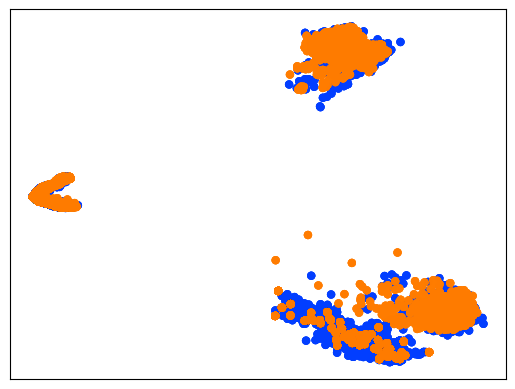

/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3519, 0.0374, 0.0262, 0.0217, 0.0193])
Vis Expl Vars: tensor(0.3519) tensor(0.0374)


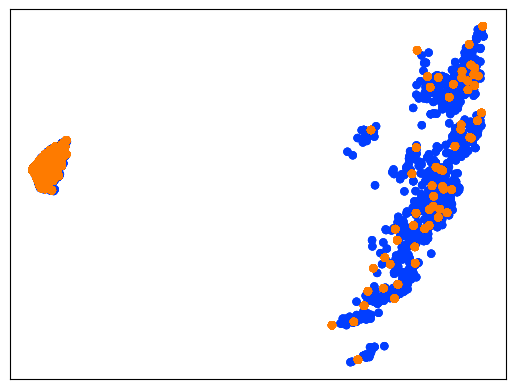

/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.4511, 0.0490, 0.0312, 0.0204, 0.0166])
Vis Expl Vars: tensor(0.4511) tensor(0.0490)


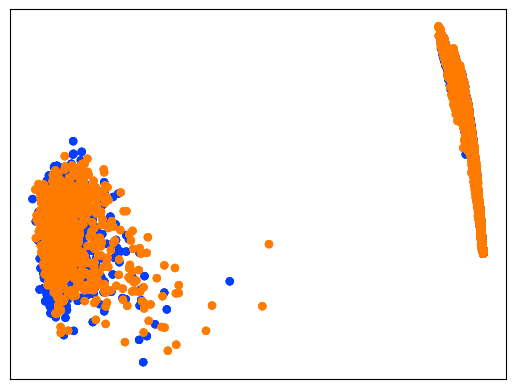

/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3735, 0.0354, 0.0233, 0.0199, 0.0156])
Vis Expl Vars: tensor(0.3735) tensor(0.0354)


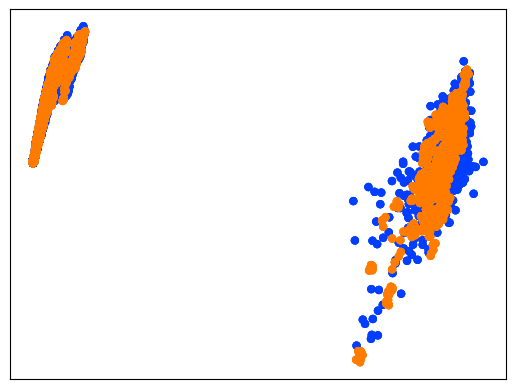

/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3811, 0.0351, 0.0174, 0.0145, 0.0129])
Vis Expl Vars: tensor(0.3811) tensor(0.0351)


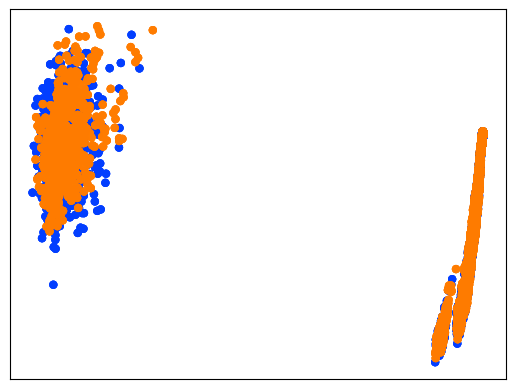

In [37]:
from divergence_utils import visualize_states, collect_divergences
np.random.seed(12345)
torch.manual_seed(12345)

base_hstates = main_hstates

print()
d = main_hstates.shape[-1]
natty_states = base_hstates.reshape(-1,d).float().cpu()
intrv_states = mod_hstates .reshape(-1,d).float().cpu()
visualize_states(
    natty_states,
    intrv_states,
    xdim=0,
    ydim=1,
    save_name=f"figs/attn_weights_alllayers.png",
    expl_var_threshold=0,
    visualize=True,
    verbose=True,
)
for pos in range(main_hstates.shape[2]):
    natty_states = base_hstates[:,:,pos].reshape(-1,d).float().cpu()
    intrv_states = mod_hstates [:,:,pos].reshape(-1,d).float().cpu()
    visualize_states(
        natty_states,
        intrv_states,
        xdim=0,
        ydim=1,
        save_name=f"figs/attn_weights_alllayers_pos{pos}.png",
        expl_var_threshold=0,
        visualize=True,
        verbose=True,
    )

/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3519, 0.0374, 0.0262, 0.0217, 0.0193])
Vis Expl Vars: tensor(0.3519) tensor(0.0374)


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:192: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().set_visible(False)


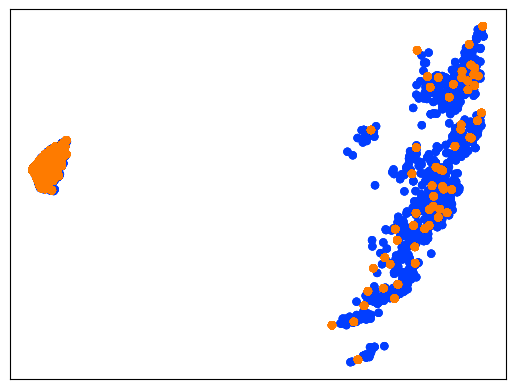

Layer: 0 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3224, 0.2526, 0.1328, 0.1163, 0.0359])
Vis Expl Vars: tensor(0.3224) tensor(0.2526)


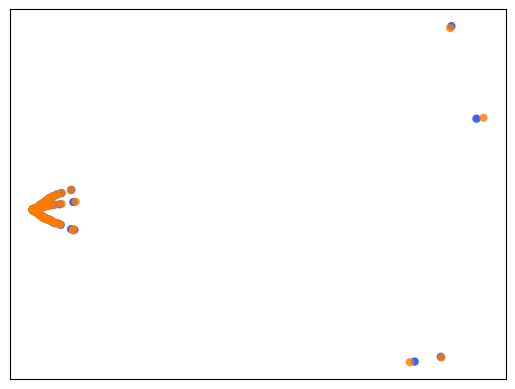

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 1 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3224, 0.2526, 0.1328, 0.1163, 0.0359])
Vis Expl Vars: tensor(0.3224) tensor(0.2526)


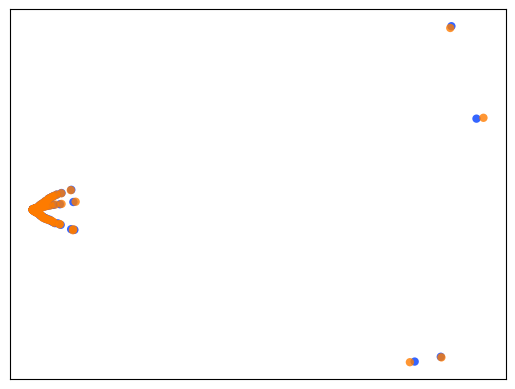

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 2 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3224, 0.2526, 0.1328, 0.1163, 0.0359])
Vis Expl Vars: tensor(0.3224) tensor(0.2526)


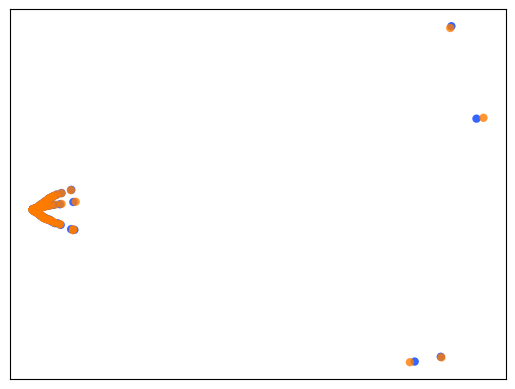

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 3 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3224, 0.2526, 0.1328, 0.1163, 0.0359])
Vis Expl Vars: tensor(0.3224) tensor(0.2526)


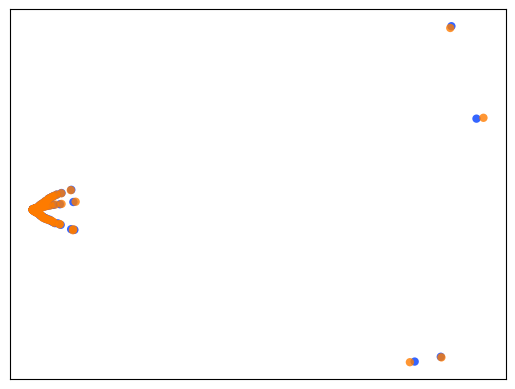

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 4 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3363, 0.2586, 0.1300, 0.1094, 0.0352])
Vis Expl Vars: tensor(0.3363) tensor(0.2586)


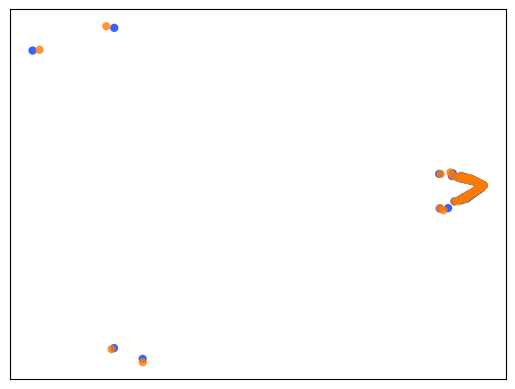

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 5 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3363, 0.2586, 0.1300, 0.1094, 0.0352])
Vis Expl Vars: tensor(0.3363) tensor(0.2586)
Error saving figure to figs/mean_diff_layer5_pos0.png


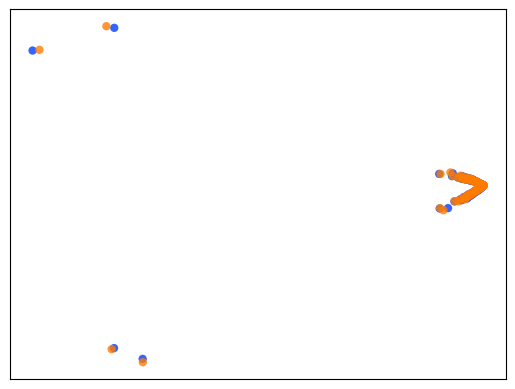

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 6 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3363, 0.2586, 0.1300, 0.1094, 0.0352])
Vis Expl Vars: tensor(0.3363) tensor(0.2586)


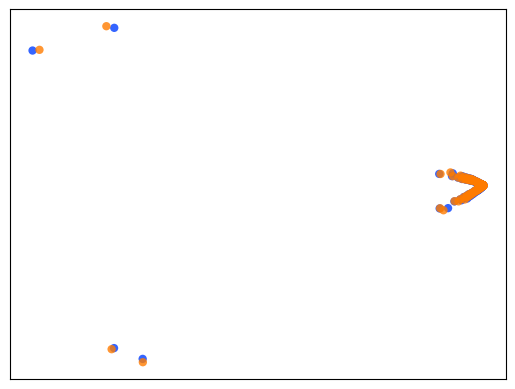

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 7 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3363, 0.2586, 0.1300, 0.1094, 0.0352])
Vis Expl Vars: tensor(0.3363) tensor(0.2586)


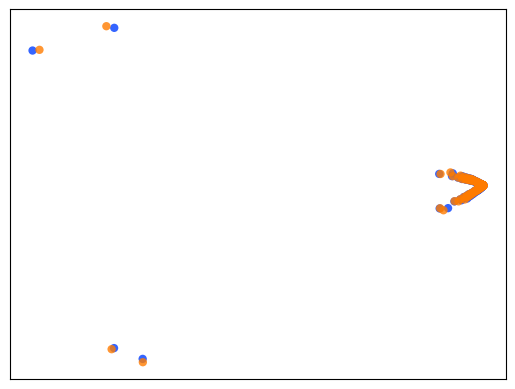

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 8 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3329, 0.2523, 0.1209, 0.1110, 0.0359])
Vis Expl Vars: tensor(0.3329) tensor(0.2523)


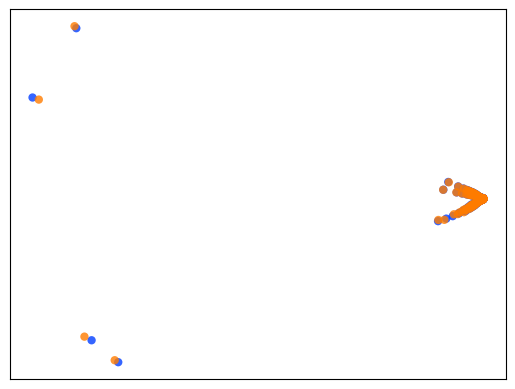

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 9 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3329, 0.2523, 0.1209, 0.1110, 0.0359])
Vis Expl Vars: tensor(0.3329) tensor(0.2523)


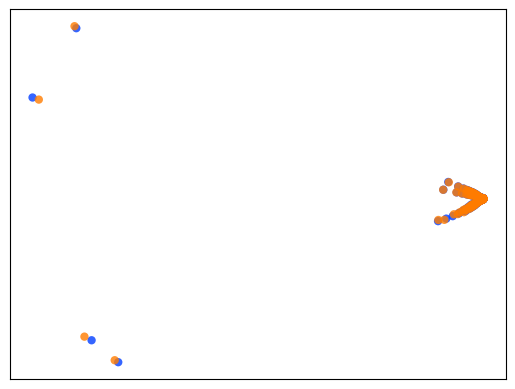

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 10 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3329, 0.2523, 0.1209, 0.1110, 0.0359])
Vis Expl Vars: tensor(0.3329) tensor(0.2523)


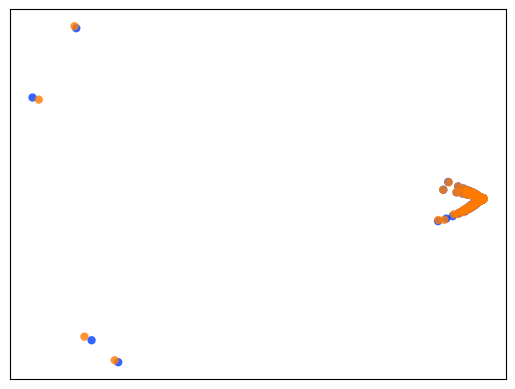

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 11 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3329, 0.2523, 0.1209, 0.1110, 0.0359])
Vis Expl Vars: tensor(0.3329) tensor(0.2523)


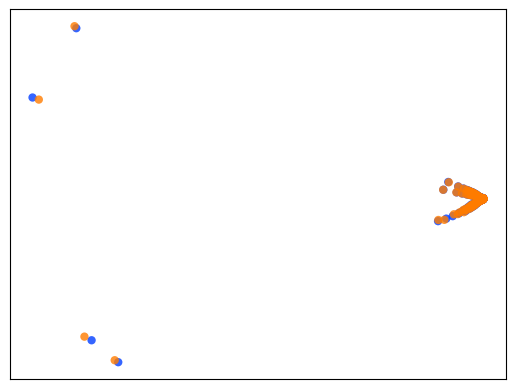

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 12 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3237, 0.2408, 0.1303, 0.1159, 0.0378])
Vis Expl Vars: tensor(0.3237) tensor(0.2408)


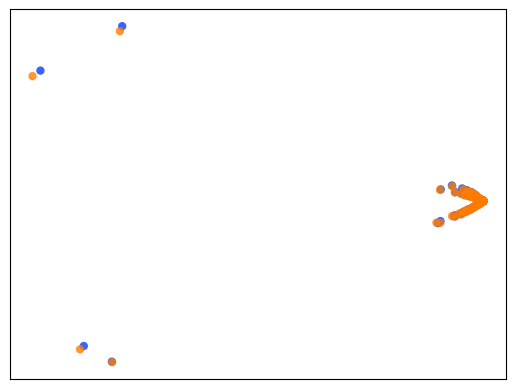

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 13 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3237, 0.2408, 0.1303, 0.1159, 0.0378])
Vis Expl Vars: tensor(0.3237) tensor(0.2408)


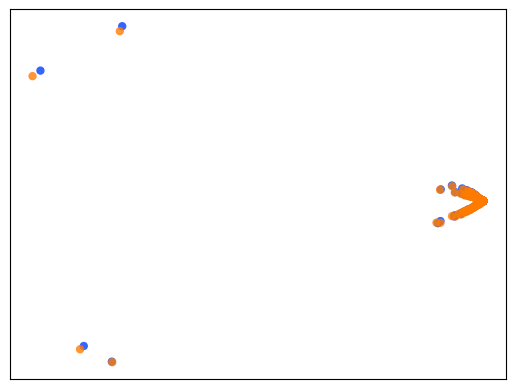

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 14 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3237, 0.2408, 0.1303, 0.1159, 0.0378])
Vis Expl Vars: tensor(0.3237) tensor(0.2408)


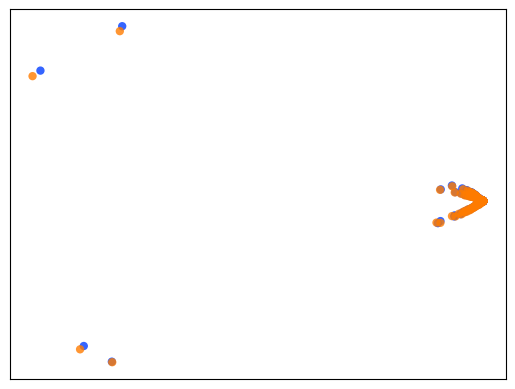

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 15 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:843: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "means": torch.tensor(means),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:844: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "stds": torch.tensor(stds),
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:255: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expl_vars = torch.tensor(ret["proportion_expl_var"]).float().cpu()
/home/grantsrb/src/rep_divergence/divergence/divergence_utils.py:177: U

x-dim: 0
y-dim: 1
Top Expl Vars: tensor([0.3237, 0.2408, 0.1303, 0.1159, 0.0378])
Vis Expl Vars: tensor(0.3237) tensor(0.2408)


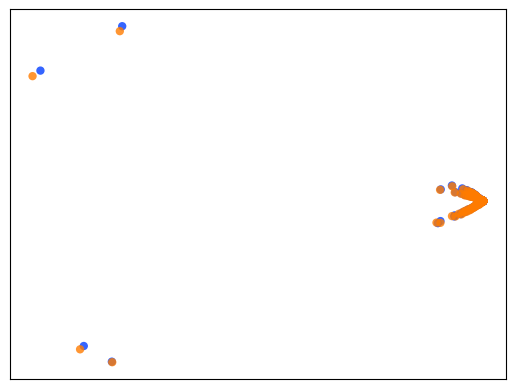

Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Computing EMD
Computing Cosine Cost
Computing Nearest Neighbor Cost Cosine
Computing MSE Cost
Computing Nearest Neighbor Cost MSE
Layer: 16 Pos: 0
Natty: torch.Size([132, 4096])
Intrv: torch.Size([132, 4096])


KeyboardInterrupt: 

In [ ]:
from divergence_utils import visualize_states, collect_divergences
np.random.seed(12345)
torch.manual_seed(12345)

base_hstates = main_hstates
all_layers = False
n_samples = 1
sample_size = 5000
layer = None
pos = None

emd_df_dict = {
    "sample_id": [],
    "pos": [],
    "layer": [],
    "mse": [],
    "emd": [],
    "base_emd": [],
}

print()
for layer in range(len(model.model.layers)):
    d = main_hstates.shape[-1]
    if all_layers:
        natty_states = base_hstates.reshape(-1,d).float().cpu()
        intrv_states = mod_hstates.reshape(-1,d).float().cpu()
    else:
        natty_states = base_hstates[layer].reshape(-1,d).float().cpu()
        intrv_states = mod_hstates[layer].reshape(-1,d).float().cpu()
    print("Layer:", layer, "Pos:", pos)
    print("Natty:", natty_states.shape)
    print("Intrv:", intrv_states.shape)
    for samp_id in range(n_samples):
        p = str(pos)
        if samp_id==0:
            perm = torch.randperm(natty_states.shape[0]).long()[:sample_size]
            visualize_states(
                natty_states[perm],
                intrv_states[perm],
                xdim=0,
                ydim=1,
                save_name=f"figs/mean_diff_layer{layer}_pos{p}.png",
                expl_var_threshold=0,
                visualize=samp_id==0,
                #verbose=samp_id==0,
            )
        diffs = collect_divergences(
            natty_vecs=natty_states,
            intrv_vecs=intrv_states,
            sample_size=sample_size,
            compute_all_divergences=False,
        )
        mse = diffs["mse"]
        emd = diffs["emd"]
        base_emd = diffs["base_emd"]
        emd_df_dict["sample_id"].append(samp_id)
        emd_df_dict["pos"].append(pos)
        emd_df_dict["layer"].append(layer)
        for k,v in diffs.items():
            if k not in emd_df_dict:
                emd_df_dict[k] = []
            emd_df_dict[k].append(float(v))
    if all_layers:
        break
    
emd_df = pd.DataFrame(emd_df_dict)
emd_df[["base_emd","emd",]].mean()
    

In [30]:
intrv_cols = ["emd", "cost_cos","nn_cos", "cost_mse", "nn_mse"]
base_cols = ["base_"+c for c in intrv_cols]
zipped = []
for c, bc in zip(intrv_cols, base_cols):
    zipped.append(bc)
    zipped.append(c)
emd_df[["layer"]+zipped].groupby("layer").mean()

,base_emd,emd,base_cost_cos,cost_cos,base_nn_cos,nn_cos,base_cost_mse,cost_mse,base_nn_mse,nn_mse
layer,,,,,,,,,,
0,15.726757,16.633001,0.169989,0.140304,0.054887,0.079225,0.173523,0.176978,0.003485,0.011848
1,32.196136,6.566019,0.148584,0.135811,0.060698,0.068923,0.242840,0.014899,0.231645,0.011508
2,15.427401,29.148203,0.158441,0.136289,0.070339,0.073858,0.095495,0.147791,0.084775,0.140227
3,9.411152,28.277208,0.146328,0.132797,0.056661,0.080599,0.091321,0.146677,0.081761,0.062770
4,7.754250,33.834103,0.172883,0.166639,0.062769,0.046044,0.095691,0.257352,0.060495,0.003876
5,27.463902,17.170349,0.146646,0.140184,0.061210,0.082216,0.161998,0.181269,0.003845,0.171663
6,12.467628,29.084663,0.110852,0.185765,0.042604,0.095871,0.076399,0.238212,0.002182,0.172412
7,1.233841,30.938597,0.141178,0.160998,0.058131,0.088313,0.013857,0.233570,0.001961,0.059597
8,13.434302,28.408300,0.161456,0.142669,0.076202,0.083095,0.083831,0.151064,0.075488,0.146998


In [32]:
mean_df = emd_df[["layer"]+zipped].groupby("layer").mean().reset_index()
diff_cols = []
for c,bc in zip(intrv_cols, base_cols):
    diff_cols.append("diff_"+c)
    mean_df["diff_"+c] = mean_df[c] - mean_df[bc]
mean_df[diff_cols].sum()/len(mean_df)


diff_emd         1.933106
diff_cost_cos    0.020081
diff_nn_cos      0.021276
diff_cost_mse    0.034360
diff_nn_mse      0.044480
dtype: float64